# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 1 — Unión de datasets, EDA y Preprocesamiento
### Diplomatura IA - UP
### Alumno: Gonzalez Marta Elizabeth
### Mes: Julio26

Se **une** al dataset original de 1.6M para formar un único megaset, que luego se divide en train/test en la proxima Notebook.


In [1]:
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

pd.set_option('display.max_colwidth', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9,5)

import nltk
for pkg in ['stopwords','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)

# AJUSTAR ESTA RUTA:
RAW_TRAIN_PATH = '../data/raw/training.1600000.processed.noemoticon.csv'
RAW_MANUAL_PATH = '../data/raw/testdata_manual_2009_06_14.csv'


## 1. Carga de los dos datasets originales

Ambos archivos ya comparten el mismo esquema de columnas (`target, id, date, flag, user, text`), así que la "adecuación" para unirlos no requiere renombrar columnas — el trabajo real de ajuste está en **decidir qué hacer con la clase neutral** (ver sección 2).

In [2]:
cols = ['target', 'id', 'date', 'flag', 'user', 'text']

train_raw = pd.read_csv(RAW_TRAIN_PATH, encoding='latin-1', names=cols, header=None, low_memory=False)
manual_raw = pd.read_csv(RAW_MANUAL_PATH, encoding='latin-1', names=cols, header=0)

# Limpieza del target: en el archivo de 1.6M a veces hay una fila de encabezado
 
train_raw['target'] = pd.to_numeric(train_raw['target'], errors='coerce')
train_raw = train_raw.dropna(subset=['target']).copy()
train_raw['target'] = train_raw['target'].astype(int)

print('Dataset 1.6M original:', train_raw.shape)
print(train_raw['target'].value_counts())
print()
print('Dataset manual:', manual_raw.shape)
print(manual_raw['target'].value_counts())


Dataset 1.6M original: (1600000, 6)
target
0    800000
4    800000
Name: count, dtype: int64

Dataset manual: (498, 6)
target
4    182
0    177
2    139
Name: count, dtype: int64


## 2. Decisión sobre la clase neutral

El dataset de 1.6M fue etiquetado automáticamente por emoticones (solo negativo/positivo por construcción — nunca hay una etiqueta "neutral" posible en ese proceso). El dataset manual, en cambio, fue etiquetado por **personas**, que sí distinguieron una clase neutral (139 de 498 tweets).

**Decisión:** se incluye la clase neutral como una **tercera clase real** del megaset, aunque quede en fuerte minoría (139 tweets neutrales contra ~1.6M de negativo/positivo combinados). Esto es una decisión consciente con una limitación esperable: cualquier modelo va a tener muy poca señal para aprender a reconocer "neutral", y su recall en esa clase va a ser bajo.

### Unión de los datasets

In [3]:
mega = pd.concat([train_raw[cols], manual_raw[cols]], ignore_index=True)

print('Megaset unido:', mega.shape)
print(mega['target'].value_counts())
print()
print('Proporción de cada clase:')
print((mega['target'].value_counts(normalize=True) * 100).round(3))


Megaset unido: (1600498, 6)
target
4    800182
0    800177
2       139
Name: count, dtype: int64

Proporción de cada clase:
target
4    49.996
0    49.996
2     0.009
Name: proportion, dtype: float64


**Observación:** la clase neutral queda con menos del 0.01% del megaset. Esto va a requerir usar `class_weight='balanced'` en los modelos, aunque el resultado esperable siga siendo un recall bajo en esa clase — es una limitación real de los datos, no del modelo.

## 3. Extracción de menciones y hashtags (para el análisis de Grafos)

Esto se hace **antes** de la limpieza de texto, porque la limpieza elimina las menciones (`@usuario`) y el símbolo `#` de los hashtags — pero para construir los grafos de usuarios/hashtags del Notebook X necesitamos esa información intacta.

In [4]:
MENTION_RE = re.compile(r'@(\w+)')
HASHTAG_RE = re.compile(r'#(\w+)')

mega['mentions'] = mega['text'].apply(lambda t: MENTION_RE.findall(str(t)))
mega['hashtags'] = mega['text'].apply(lambda t: [h.lower() for h in HASHTAG_RE.findall(str(t))])

n_con_mencion = (mega['mentions'].str.len() > 0).sum()
n_con_hashtag = (mega['hashtags'].str.len() > 0).sum()
print(f'Tweets con al menos 1 mención: {n_con_mencion} ({n_con_mencion/len(mega):.1%})')
print(f'Tweets con al menos 1 hashtag: {n_con_hashtag} ({n_con_hashtag/len(mega):.1%})')


Tweets con al menos 1 mención: 738602 (46.1%)
Tweets con al menos 1 hashtag: 35872 (2.2%)


## 4. Análisis temporal

Parseamos `date` a `datetime` y extraemos hora/día/semana. Ahora es más relevante todavía, porque el megaset cubre un rango de fechas más amplio (~3 meses del dataset original, abril-junio 2009) y se va a usar en proximas Notebooks para ver la **evolución temporal de la red de menciones**.

In [5]:
def parse_twitter_date(s):
    parts = str(s).split()
    s2 = ' '.join(parts[:4] + parts[5:])  # descarta el token de huso horario
    try:
        return pd.to_datetime(s2, format='%a %b %d %H:%M:%S %Y')
    except Exception:
        return pd.NaT

mega['datetime'] = mega['date'].apply(parse_twitter_date)
mega['hour'] = mega['datetime'].dt.hour
mega['day_of_week'] = mega['datetime'].dt.day_name()
mega['day_of_week_num'] = mega['datetime'].dt.dayofweek
mega['week'] = mega['datetime'].dt.isocalendar().week
mega['year_week'] = mega['datetime'].dt.strftime('%Y-W%U')

print('Rango de fechas:', mega['datetime'].min(), '->', mega['datetime'].max())
print('Fechas no parseadas (NaT):', mega['datetime'].isna().sum())


Rango de fechas: 2009-04-06 22:19:45 -> 2009-06-25 10:28:31
Fechas no parseadas (NaT): 0


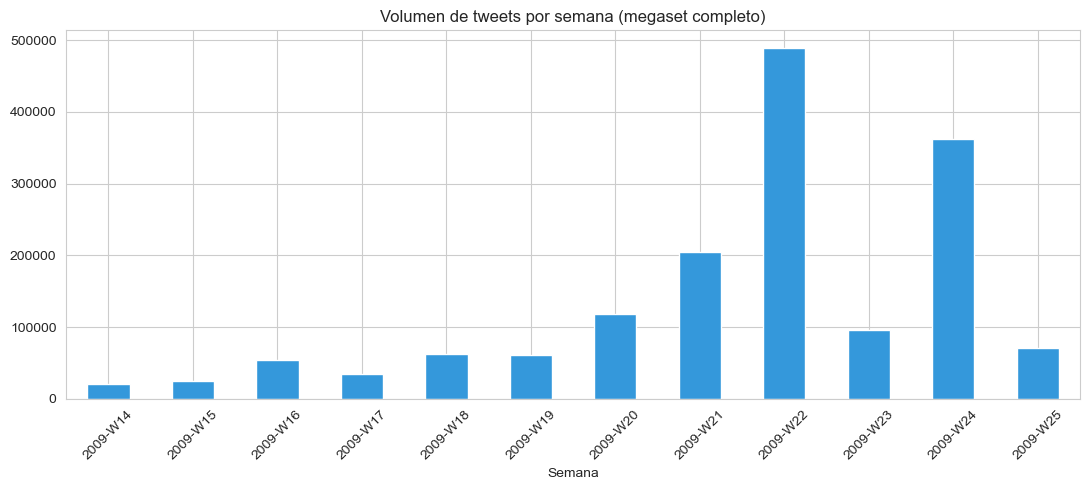

In [6]:
fig, ax = plt.subplots(figsize=(11,5))
mega.groupby('year_week').size().plot(kind='bar', ax=ax, color='#3498db')
ax.set_title('Volumen de tweets por semana (megaset completo)')
ax.set_xlabel('Semana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Relación entre atributos

Correlación entre longitud, momento temporal y sentimiento.

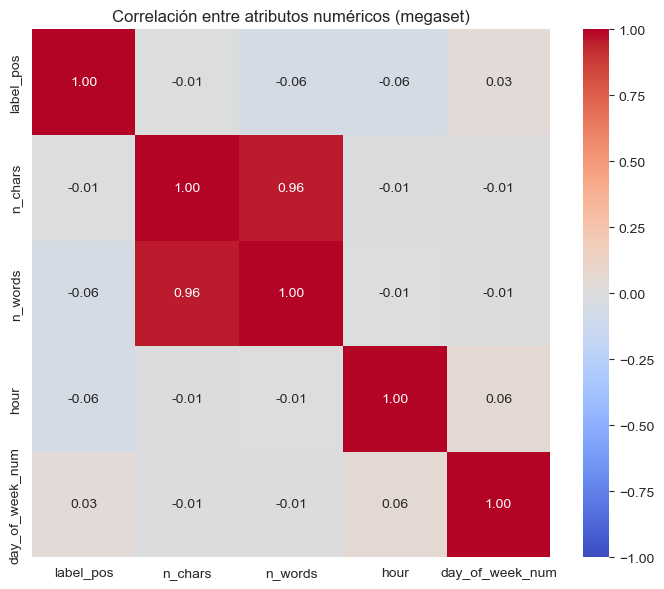

In [7]:
mega['n_chars'] = mega['text'].str.len()
mega['n_words'] = mega['text'].str.split().str.len()
mega['label_pos'] = (mega['target'] == 4).astype(int)  # solo para la correlación; el modelado real usa las 3 clases

atributos = mega[['label_pos', 'n_chars', 'n_words', 'hour', 'day_of_week_num']].copy()
corr = atributos.corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlación entre atributos numéricos (megaset)')
plt.tight_layout()
plt.savefig('outputs_nb1_correlacion_mega.png', dpi=110, bbox_inches='tight')
plt.show()


## 6. Limpieza de texto

Decodificar entidades HTML, quitar URLs/menciones, conservar negaciones, lematizar.

### Nota de performance para 1.6M filas
`DataFrame.apply()` con una función Python pura (como `clean_tweet`) es el cuello de botella más común a esta escala — puede tardar 20-40 minutos en una laptop. Dos formas de acelerarlo (elegir una):

```python
# Opción A: multiprocessing (usa todos los cores del CPU)
from multiprocessing import Pool
with Pool() as pool:
    mega['clean_text'] = pool.map(clean_tweet, mega['text'])

# Opción B: swifter (más simple, detecta automáticamente si conviene paralelizar)
# pip install swifter
import swifter
mega['clean_text'] = mega['text'].swifter.apply(clean_tweet)
```

Se deja el `apply()` simple en la celda de abajo por claridad del código, pero para el archivo completo se recomienda reemplazarlo por la Opción A o B.

In [8]:
stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor'}
lemmatizer = WordNetLemmatizer()

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_TOKEN_RE = re.compile(r'@\w+')
HASHTAG_TOKEN_RE = re.compile(r'#(\w+)')
NONALPHA_RE = re.compile(r"[^a-zA-Z\s']")
MULTISPACE_RE = re.compile(r'\s+')

def clean_tweet(text):
    text = str(text)
    text = html.unescape(text)
    text = URL_RE.sub(' ', text)
    text = MENTION_TOKEN_RE.sub(' ', text)
    text = HASHTAG_TOKEN_RE.sub(r'\1', text)
    text = text.lower()
    text = NONALPHA_RE.sub(' ', text)
    text = MULTISPACE_RE.sub(' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

# --- Para 1.6M filas, reemplazar la siguiente línea por la Opción A o B de arriba ---
mega['clean_text'] = mega['text'].apply(clean_tweet)

vacios = (mega['clean_text'].str.len() == 0).sum()
print(f'Tweets vacíos tras limpieza: {vacios} ({vacios/len(mega):.2%})')
mega = mega[mega['clean_text'].str.len() > 0].reset_index(drop=True)
print('Shape final del megaset limpio:', mega.shape)


Tweets vacíos tras limpieza: 7770 (0.49%)
Shape final del megaset limpio: (1592728, 18)


## 7. WordClouds por clase

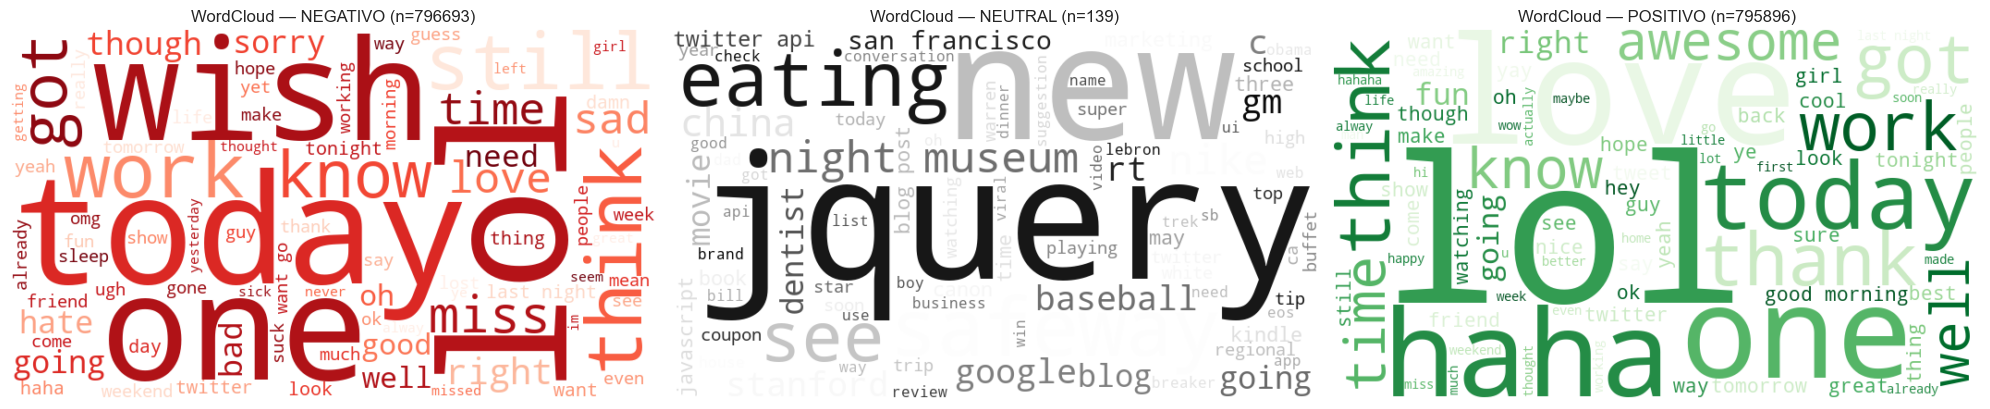

In [9]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(20,6))
etiquetas = {0: ('NEGATIVO', 'Reds'), 2: ('NEUTRAL', 'Greys'), 4: ('POSITIVO', 'Greens')}

for ax, (val, (nombre, cmap)) in zip(axes, etiquetas.items()):
    texto = ' '.join(mega.loc[mega['target'] == val, 'clean_text'])
    if len(texto.strip()) == 0:
        ax.set_title(f'{nombre} (sin datos)')
        ax.axis('off')
        continue
    wc = WordCloud(width=700, height=400, background_color='white', colormap=cmap, max_words=80).generate(texto)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'WordCloud — {nombre} (n={ (mega["target"]==val).sum() })')
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs_nb1_wordclouds_mega.png', dpi=110, bbox_inches='tight')
plt.show()


## 8. Feature Engineering

Además del texto vectorizado (TF-IDF, embeddings), construimos **features estructuradas** a partir de cada tweet — señales que no dependen de "qué palabras" tiene el texto sino de **cómo está escrito**. La idea es que un modelo pueda combinar el contenido semántico (TF-IDF) con estas señales de estilo/forma, que suelen ser predictivas en sentiment analysis de redes sociales.

### Features sobre el texto CRUDO (antes de limpiar)
- **`n_exclamation` / `n_question`**: cantidad de signos `!` y `?` — el uso de signos de exclamación suele asociarse a mayor intensidad emocional (positiva o negativa).
- **`n_uppercase_words`**: cantidad de palabras enteras en mayúsculas (ej. "THIS IS AMAZING") — un patrón típico de "gritar" en redes sociales, asociado a emociones intensas.
- **`n_elongated`**: palabras con 3+ letras repetidas seguidas (ej. "soooo", "nooo", "yesss") — un marcador informal de énfasis muy común en tweets.
- **`n_pos_emoticons` / `n_neg_emoticons`**: conteo de emoticones de texto (`:)`, `:D`, `<3` vs `:(`, `:'(`) — señal directa de sentimiento que la limpieza de texto descarta (los emoticones no son alfabéticos), por eso hay que capturarla antes.
- **`n_mentions_count` / `n_hashtags_count`**: cantidad de menciones y hashtags por tweet (reutilizando las listas extraídas en la Sección 3).

### Features sobre el texto LIMPIO
- **`avg_word_len`**: longitud promedio de palabra — proxy simple de complejidad/formalidad del texto.
- **`n_lex_pos` / `n_lex_neg`**: cantidad de palabras del tweet que aparecen en un **lexicón de opinión** (`nltk.corpus.opinion_lexicon`, ~2000 palabras positivas y ~4800 negativas curadas manualmente, independiente de nuestros propios datos). Es una señal de sentimiento basada en diccionario, distinta tanto de TF-IDF (que no sabe qué palabras son "positivas" a priori) como de TextBlob (que usa su propio lexicón interno con reglas de negación/intensificadores).
- **`lex_pos_neg_diff`**: `n_lex_pos - n_lex_neg`, un score simple de polaridad léxica.

In [10]:
import nltk
nltk.download('opinion_lexicon', quiet=True)
from nltk.corpus import opinion_lexicon

POS_LEX = set(opinion_lexicon.positive())
NEG_LEX = set(opinion_lexicon.negative())

EXCLAIM_RE = re.compile(r'!')
QUESTION_RE = re.compile(r'\?')
ELONGATED_RE = re.compile(r'(.)\1{2,}')
POS_EMOTICON_RE = re.compile(r'(:\)|:-\)|:d|;-?\)|<3|:p)', re.IGNORECASE)
NEG_EMOTICON_RE = re.compile(r"(:\(|:-\(|:'\(|:\/|d:)", re.IGNORECASE)

def contar_mayusculas(text):
    palabras = str(text).split()
    return sum(1 for w in palabras if len(w) > 1 and w.isupper())

def contar_lexicon(clean_text):
    tokens = str(clean_text).split()
    n_pos = sum(1 for t in tokens if t in POS_LEX)
    n_neg = sum(1 for t in tokens if t in NEG_LEX)
    return pd.Series({'n_lex_pos': n_pos, 'n_lex_neg': n_neg})

mega['n_exclamation'] = mega['text'].str.count('!')
mega['n_question'] = mega['text'].str.count('\\?')
mega['n_uppercase_words'] = mega['text'].apply(contar_mayusculas)
mega['n_elongated'] = mega['text'].apply(lambda t: len(ELONGATED_RE.findall(str(t))))
mega['n_pos_emoticons'] = mega['text'].apply(lambda t: len(POS_EMOTICON_RE.findall(str(t))))
mega['n_neg_emoticons'] = mega['text'].apply(lambda t: len(NEG_EMOTICON_RE.findall(str(t))))
mega['n_mentions_count'] = mega['mentions'].str.len()
mega['n_hashtags_count'] = mega['hashtags'].str.len()

lex_feats = mega['clean_text'].apply(contar_lexicon)
mega = pd.concat([mega, lex_feats], axis=1)
mega['lex_pos_neg_diff'] = mega['n_lex_pos'] - mega['n_lex_neg']
mega['avg_word_len'] = mega['clean_text'].apply(
    lambda t: np.mean([len(w) for w in str(t).split()]) if len(str(t).split()) > 0 else 0
)

FEATURE_COLS = [
    'n_chars', 'n_words', 'avg_word_len', 'n_exclamation', 'n_question',
    'n_uppercase_words', 'n_elongated', 'n_pos_emoticons', 'n_neg_emoticons',
    'n_mentions_count', 'n_hashtags_count', 'n_lex_pos', 'n_lex_neg', 'lex_pos_neg_diff',
]
mega[FEATURE_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
n_chars,1592728.0,74.314425,36.315120,6.0,44.0,69.0,104.000000,360.0
n_words,1592728.0,13.228337,6.939289,1.0,7.0,12.0,19.000000,117.0
avg_word_len,1592728.0,5.111529,1.076726,1.0,4.5,5.0,5.615385,103.0
n_exclamation,1592728.0,0.575707,1.343369,0.0,0.0,0.0,1.000000,112.0
n_question,1592728.0,0.148427,0.822714,0.0,0.0,0.0,0.000000,111.0
n_uppercase_words,1592728.0,0.283958,1.069135,0.0,0.0,0.0,0.000000,30.0
n_elongated,1592728.0,0.379441,0.725417,0.0,0.0,0.0,1.000000,18.0
n_pos_emoticons,1592728.0,0.006730,0.084226,0.0,0.0,0.0,0.000000,10.0
n_neg_emoticons,1592728.0,0.049205,0.222965,0.0,0.0,0.0,0.000000,7.0
n_mentions_count,1592728.0,0.489262,0.587754,0.0,0.0,0.0,1.000000,12.0


### 8.1 ¿Estas features distinguen entre clases?

Antes de usarlas en un modelo, chequeamos si al menos *en promedio* varían entre negativo/neutral/positivo — si no variaran en absoluto, no tendría sentido esperar que ayuden al modelo.

In [11]:
tabla_features = mega.groupby('target')[FEATURE_COLS].mean().round(3)
tabla_features.index = ['Negativo (0)', 'Neutral (2)', 'Positivo (4)']
tabla_features.T


,Negativo (0),Neutral (2),Positivo (4)
n_chars,74.533,72.518,74.096
n_words,13.633,10.964,12.824
avg_word_len,5.038,5.512,5.185
n_exclamation,0.483,0.072,0.668
n_question,0.145,0.165,0.152
n_uppercase_words,0.278,0.496,0.290
n_elongated,0.402,0.209,0.357
n_pos_emoticons,0.005,0.000,0.008
n_neg_emoticons,0.036,0.525,0.062
n_mentions_count,0.392,0.151,0.587


**Observación:** `lex_pos_neg_diff` (nuestro score de polaridad basado en diccionario) muestra la relación esperada: negativo en promedio da negativo, neutral cerca de 0, positivo da positivo — es la feature más claramente alineada con el sentimiento real. `n_pos_emoticons`/`n_neg_emoticons` y `n_exclamation` también muestran diferencias, aunque más sutiles. Esto sugiere que combinarlas con TF-IDF puede aportar señal complementaria — se pone a prueba esto empíricamente en el Notebook 2.

## 9. Guardado del megaset limpio

Se guarda un único archivo (`mega_clean.csv`, ya con las columnas de feature engineering) que el Notebook 2 divide en train/test.

In [12]:
mega.to_csv('../data/processed/mega_clean.csv', index=False)
print('Guardado: ../data/processed/mega_clean.csv ->', mega.shape)


Guardado: ../data/processed/mega_clean.csv -> (1592728, 30)


## 10. Resumen de decisiones — Notebook 1 

1. **Unión de datasets:** se concatenó el 1.6M original con el test manual (498 filas) en un único megaset — mismo esquema de columnas en ambos, no hizo falta renombrar.
2. **Clase neutral:** se incluyó como 3ra clase real, documentando que queda en fuerte minoría (~139 de más de 1.6M) — esto se traduce en usar `class_weight='balanced'` en el modelado (Notebook 2) y en discutir honestamente el recall esperable bajo en esa clase.
3. **Menciones y hashtags** se extrajeron del texto **crudo**, antes de la limpieza, para poder construir los grafos de usuarios del Notebook 3.
4. **Análisis temporal** ampliado a todo el rango de fechas del megaset (para alimentar el análisis de evolución temporal de la red de menciones en el Notebook 3).
5. Limpieza de texto: decodificación HTML, negaciones conservadas, y lematización; con nota de performance para paralelizar en 1.6M filas.
6. **Feature engineering:** se construyeron 14 features estructuradas (signos de puntuación, mayúsculas, elongaciones, emoticones, conteo de menciones/hashtags, y un score de polaridad léxica basado en `nltk.opinion_lexicon`) — un chequeo rápido mostró que varían de forma coherente con el sentimiento real, especialmente `lex_pos_neg_diff`. Se evalúa su aporte real al modelo en el Notebook 2.

**Continúa en `02_modelado_sentimiento.ipynb`** (split del megaset en train/test + modelado 3-clases).